In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from statistical_analysis_and_plots import get_data, bootstrap_confidence_interval

from tqdm.auto import tqdm
import torch

/gpfs/data/chopralab/singhr36/miniconda/envs/d1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dict_mc_scores, dict_judge_scores, dict_importance_weights, prompt_category_index, all_outputs, _ = get_data(
        "output_paraphrases_est_unsafe_to_unsafe/", 
    save_cheap_model_output=False, 
    min_sample_size=1000, 
    model_name_to_load='Llama',
    )

Model: Llama-3.1-8B-Instruct, Experiment: 20260118_145600
Not outptutting model responses and completion ids to save memory since we only need the scores for analysis.
Including Limit Samples: [3750, 5000]
MC Scores Shape: torch.Size([1250, 10000]), IS Scores Shape: torch.Size([1250, 500])
CEM True, Ablation 1.0, Num Particles 500, Seed 44
MC Mean:  tensor(0.0186, dtype=torch.float64)
-----


Model: Llama-3.1-8B-Instruct, Experiment: 20260118_145352
Not outptutting model responses and completion ids to save memory since we only need the scores for analysis.
Including Limit Samples: [0, 1250]
MC Scores Shape: torch.Size([1250, 10000]), IS Scores Shape: torch.Size([1250, 500])
CEM True, Ablation 1.0, Num Particles 500, Seed 44
MC Mean:  tensor(0.0366, dtype=torch.float64)
-----


Model: Llama-3.1-8B-Instruct, Experiment: 20260118_121648
Skipping Llama-3.1-8B-Instruct_500_42 because it has less than 1000 samples.
Model: Llama-3.1-8B-Instruct, Experiment: 20260118_145419
Not outptutting mo

In [3]:
dict_judge_scores.keys()

dict_keys(['Llama-3.1-8B-Instruct_500_44_limit_3750_5000', 'Llama-3.1-8B-Instruct_500_44_limit_0_1250', 'Llama-3.1-8B-Instruct_500_44_limit_2500_3750', 'Llama-3.1-8B-Instruct_500_44_limit_5000_6250', 'Llama-3.1-8B-Instruct_500_44_limit_6250_7825', 'Llama-3.1-8B-Instruct_500_44_limit_1250_2500'])

In [4]:
def merge_data(dict_judge_scores, dict_importance_weights):

    all_para_is_grouped = torch.zeros(309, 25)
    for key in dict_judge_scores:
        all_judge = dict_judge_scores[key]
        all_iw = dict_importance_weights[key]
    
        all_is = (dict_judge_scores[key] > 0.75).float() *  dict_importance_weights[key].squeeze(2)
        
        n_prompts = all_is.shape[0] // 25
            
        limit_samples = [int(x) // 25 for x in key.split('limit')[1].split('_')[1:]]    
        para_is_grouped = torch.cat([all_is[25 * idx: 25 * (idx + 1)].unsqueeze(0) for idx in range(n_prompts)], dim=0).mean(dim=2)    
        
        left_index = limit_samples[0]
        right_index = limit_samples[1]
        
        print(left_index, right_index, para_is_grouped.shape)
        
        all_para_is_grouped[left_index: min(right_index, left_index + para_is_grouped.shape[0])] = para_is_grouped
    
        print(key, para_is_grouped.shape)

    return all_para_is_grouped

all_para_is_grouped = merge_data(dict_judge_scores, dict_importance_weights)
all_para_is_grouped.shape

150 200 torch.Size([50, 25])
Llama-3.1-8B-Instruct_500_44_limit_3750_5000 torch.Size([50, 25])
0 50 torch.Size([50, 25])
Llama-3.1-8B-Instruct_500_44_limit_0_1250 torch.Size([50, 25])
100 150 torch.Size([50, 25])
Llama-3.1-8B-Instruct_500_44_limit_2500_3750 torch.Size([50, 25])
200 250 torch.Size([50, 25])
Llama-3.1-8B-Instruct_500_44_limit_5000_6250 torch.Size([50, 25])
250 313 torch.Size([59, 25])
Llama-3.1-8B-Instruct_500_44_limit_6250_7825 torch.Size([59, 25])
50 100 torch.Size([50, 25])
Llama-3.1-8B-Instruct_500_44_limit_1250_2500 torch.Size([50, 25])


torch.Size([309, 25])

In [5]:
prompt_category_index.keys(), [len(prompt_category_index[key]) for key in prompt_category_index]

(dict_keys(['Disinformation and deception', 'Hate, harassment and discrimination', 'Illegal goods and services', 'Non-violent crimes', 'Sexual content', 'Violence']),
 [50, 50, 50, 59, 50, 54])

In [6]:
def empirical_cdf(x):
    x = np.sort(np.asarray(x))
    n = len(x)

    def cdf(t):
        return np.searchsorted(x, t, side='right') / n

    return cdf
    
def permute(x):
    n = len(x)
    random_indices = torch.randperm(n)
    return x[random_indices]
permute(torch.arange(10))    

tensor([9, 0, 8, 2, 7, 4, 1, 6, 5, 3])

In [7]:
torch.cat([torch.ones(10).unsqueeze(0)*_ for _ in range(2)], dim=0), torch.cat([torch.ones(10).unsqueeze(0)*_ for _ in range(2)], dim=0).flatten()

(tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.]))

In [9]:
import os
import random
import numpy as np
import torch

def seed_everything(seed: int, deterministic: bool = True):
    # Python
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    return seed

seed_everything(42)

42

In [10]:
all_data = all_para_is_grouped.flatten()
all_data = permute(all_data)


n_train = int(len(all_data) * 0.3)
train_data = all_data[:n_train]
test_data = all_data[n_train:]

train_data.shape, test_data.shape, all_data.shape

(torch.Size([2317]), torch.Size([5408]), torch.Size([7725]))

In [11]:
def empirical_estimator_for_max_prob(data, n_queries, prob):
    n_trial = 800
    val = sum([permute(data)[:n_queries].max() > prob for _ in range(n_trial)])/n_trial

    return val

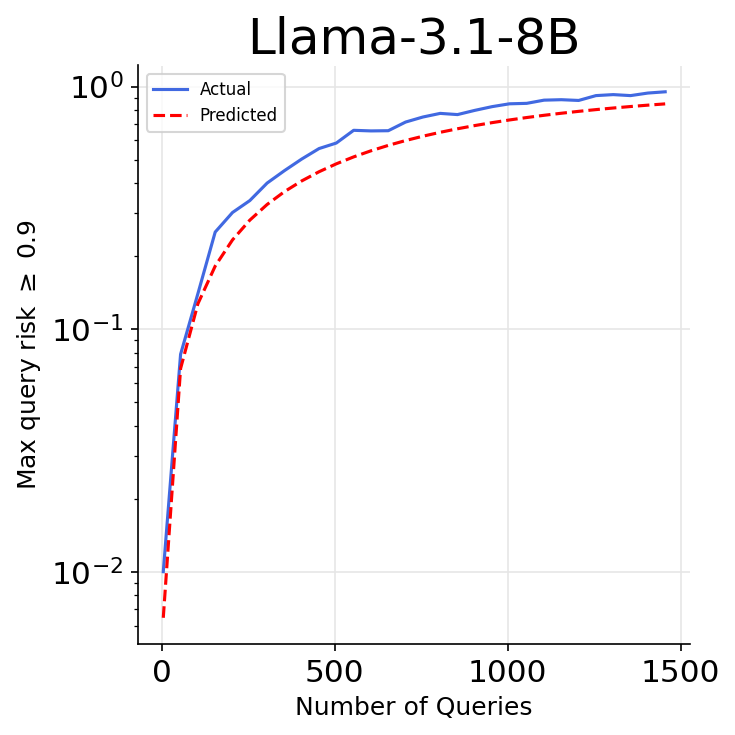

In [41]:
cdf_estimator = empirical_cdf(train_data)
prob = 0.9
n_queries = range(5, 1500, 50)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)

test_val = [empirical_estimator_for_max_prob(test_data, n_query, prob=prob) for n_query in n_queries]
predicted_val = [1-cdf_estimator(prob)**n_query for n_query in n_queries]

ax.set_title('Llama-3.1-8B'.split('_')[0].replace('-Instruct', '').replace('phi', 'Phi'), fontsize=24, fontweight='regular')

ax.plot(n_queries, test_val, label='Actual', color='royalblue')
ax.plot(n_queries, predicted_val, label='Predicted', color='red', linestyle='--')


ax.set_xlabel('Number of Queries', fontsize=12, fontweight='regular')
# ax.set_ylabel(r'P$[\text{max}_{i \leq N} q-\text{RISK}(\mathbf{c}_i) >$' + '$ {}]$'.format(prob), fontsize=12, fontweight='regular')
ax.set_ylabel(r'Max query risk $\geq$ {}'.format(prob), fontsize=12, fontweight='regular')

ax.grid(True, c='0.9', axis='y')
ax.grid(True, c='0.9', axis='x')

ax.set_yscale('log')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_axisbelow(True)

ax.grid(True, c='0.9', axis='y')
ax.grid(True, c='0.9', axis='x')    

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='minor', labelsize=15)

# ax.legend(loc='upper right', font)
ax.legend(loc="upper left", frameon=True, ncol=1, fontsize=8)

fig.tight_layout()
plt.savefig('max_risk_prediction.pdf')

In [13]:
test_data.mean(), train_data.mean()

(tensor(0.0106), tensor(0.0121))